# Notebook 03 — Encoded Pairs & Data Quality (Stage 6)

Deep inspection of the integer-encoded context-response pairs produced by Stage 6.

| Section | Topic |
|---------|-------|
| **C** | Pipeline config, inventory, disk sizes, config hashes |
| **D** | Sample pair inspection & decoding |
| **E** | Sequence length statistics and histograms |
| **F** | Token distribution & data quality metrics |
| **G** | Split integrity checks (leakage, ID range, SOS/EOS, __eot__) |
| **H** | Summary dashboard |


In [1]:
# === SETUP: Imports, Paths, and Helpers ===

import json
import hashlib
import math
import os
import random
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
import sentencepiece as spm
from rich.console import Console
from rich.panel import Panel
from rich.table import Table
from rich import box

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts'
VIZ_DIR      = PROJECT_ROOT / 'notebooks' / 'visualizations'
VIZ_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_JSONL  = ARTIFACT_DIR / 'stage6_train_ids.jsonl'
VAL_JSONL    = ARTIFACT_DIR / 'stage6_val_ids.jsonl'
TEST_JSONL   = ARTIFACT_DIR / 'stage6_test_ids.jsonl'
VOCAB_JSON   = ARTIFACT_DIR / 'stage6_vocab.json'
IDX2WORD_JSON= ARTIFACT_DIR / 'stage6_idx2word.json'
STAGE6_STATS = ARTIFACT_DIR / 'stage6_stats.json'
SPM_MODEL    = ARTIFACT_DIR / 'stage5_spm.model'

# Config constants from phase1.py
MAX_CTX_TOKENS  = 256
MAX_RESP_TOKENS = 50
PAD_ID, UNK_ID, SOS_ID, EOS_ID = 0, 1, 2, 3

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11,
})
sns.set_palette('muted')
console = Console(highlight=True)
random.seed(42)

def _require(path: Path, label: str = '') -> bool:
    if path.exists():
        return True
    console.print(Panel(
        f'[bold red]File not found:[/bold red] {path}\n'
        f'[yellow]Run phase1.py to generate {label or path.name}.[/yellow]',
        title='⚠  Missing Artefact', border_style='red'
    ))
    return False

def _load_jsonl_full(path: Path) -> list:
    recs = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            recs.append(json.loads(line))
    return recs

def _save_fig(fig, name: str):
    out = VIZ_DIR / f'{name}.png'
    fig.savefig(out, bbox_inches='tight', dpi=150)
    console.print(f'[green]Saved[/green] → {out}')

console.print(Panel('[bold green]Setup complete[/bold green]\n'
    f'ARTIFACT_DIR = {ARTIFACT_DIR}\n'
    f'MAX_CTX_TOKENS={MAX_CTX_TOKENS}  MAX_RESP_TOKENS={MAX_RESP_TOKENS}  (phase1 config)',
    title='Notebook 03 — Encoded Pairs & Data Quality', border_style='green'))


╭────────────────────────────────── Notebook 03 — Encoded Pairs & Data Quality ───────────────────────────────────╮
│ Setup complete                                                                                                  │
│ ARTIFACT_DIR = C:\git\nlp-final-project\artifacts                                                               │
│ MAX_CTX_TOKENS=256  MAX_RESP_TOKENS=50  (phase1 config)                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Section C — Pipeline Config & Inventory

In [2]:
# === SECTION C.1: stage6_stats.json ===

if not _require(STAGE6_STATS, 'stage6_stats.json'):
    raise SystemExit('Missing stage6 stats')

with open(STAGE6_STATS) as f:
    s6 = json.load(f)

console.print(Panel(json.dumps(s6, indent=2), title='stage6_stats.json', border_style='blue'))

VOCAB_SIZE = s6.get('vocab_size', 32000)
N_TRAIN    = s6.get('n_train', 0)
N_VAL      = s6.get('n_val', 0)
N_TEST     = s6.get('n_test', 0)

t = Table(title='Stage 6 Key Config', box=box.SIMPLE_HEAVY)
for k, v in [('vocab_size', VOCAB_SIZE), ('n_train', N_TRAIN),
              ('n_val', N_VAL), ('n_test', N_TEST),
              ('sos_id', s6.get('sos_id', 2)), ('eos_id', s6.get('eos_id', 3))]:
    t.add_row(k, str(v))
console.print(t)


╭─────────────────────────────────────────────── stage6_stats.json ───────────────────────────────────────────────╮
│ {                                                                                                               │
│   "stage": 6,                                                                                                   │
│   "vocab_size": 32000,                                                                                          │
│   "n_train": 1070445,                                                                                           │
│   "n_val": 47791,                                                                                               │
│   "n_test": 47805,                                                                                              │
│   "sos_id": 2,                                                                                                  │
│   "eos_id": 3                                                                                                   │
│ }                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

   Stage 6 Key Config   
                        
                        
 ━━━━━━━━━━━━━━━━━━━━━━ 
  vocab_size   32000    
  n_train      1070445  
  n_val        47791    
  n_test       47805    
  sos_id       2        
  eos_id       3

In [3]:
# === SECTION C.2: Line counts table for all 3 JSONL splits ===

N_TOTAL = N_TRAIN + N_VAL + N_TEST
t = Table(title='JSONL Line Counts vs Expected Split Ratios', box=box.ROUNDED)
t.add_column('Split', style='cyan')
t.add_column('Expected ~', justify='right')
t.add_column('Actual Lines', justify='right')
t.add_column('Actual %', justify='right')
t.add_column('Status', justify='center')

EXPECTED = {'train': 0.80, 'val': 0.10, 'test': 0.10}
TOLERANCE = 0.05

actual_counts = {}
for split_name, fpath, n_stat in [
    ('train', TRAIN_JSONL, N_TRAIN), ('val', VAL_JSONL, N_VAL), ('test', TEST_JSONL, N_TEST)
]:
    if not fpath.exists():
        t.add_row(split_name, '—', 'MISSING', '—', '[red]MISSING[/red]')
        actual_counts[split_name] = 0
        continue
    with open(fpath) as f:
        actual_n = sum(1 for _ in f)
    actual_counts[split_name] = actual_n
    actual_pct = actual_n / N_TOTAL if N_TOTAL > 0 else 0
    exp_pct = EXPECTED[split_name]
    ok = abs(actual_pct - exp_pct) <= TOLERANCE
    status = f'[green]OK[/green]' if ok else f'[red]WARN[/red]'
    t.add_row(split_name, f'~{exp_pct:.0%}', f'{actual_n:,}', f'{actual_pct:.1%}', status)
console.print(t)


       JSONL Line Counts vs Expected Split Ratios        
╭───────┬────────────┬──────────────┬──────────┬────────╮
│ Split │ Expected ~ │ Actual Lines │ Actual % │ Status │
├───────┼────────────┼──────────────┼──────────┼────────┤
│ train │       ~80% │    1,070,445 │    91.8% │  WARN  │
│ val   │       ~10% │       47,791 │     4.1% │  WARN  │
│ test  │       ~10% │       47,805 │     4.1% │  WARN  │
╰───────┴────────────┴──────────────┴──────────┴────────╯

In [4]:
# === SECTION C.3: Disk size table for stage 6 artifacts ===

t = Table(title='Stage 6 Artifact Disk Sizes', box=box.ROUNDED)
t.add_column('File', style='cyan')
t.add_column('Exists', justify='center')
t.add_column('Size (MB)', justify='right')

stage6_files = [
    ('stage6_train_ids.jsonl', TRAIN_JSONL),
    ('stage6_val_ids.jsonl',   VAL_JSONL),
    ('stage6_test_ids.jsonl',  TEST_JSONL),
    ('stage6_vocab.json',      VOCAB_JSON),
    ('stage6_idx2word.json',   IDX2WORD_JSON),
    ('stage6_stats.json',      STAGE6_STATS),
]
for fname, fpath in stage6_files:
    exists = fpath.exists()
    size_mb = f'{fpath.stat().st_size / 1e6:.2f}' if exists else '—'
    t.add_row(fname, '[green]✓[/green]' if exists else '[red]✗[/red]', size_mb)
console.print(t)


          Stage 6 Artifact Disk Sizes          
╭────────────────────────┬────────┬───────────╮
│ File                   │ Exists │ Size (MB) │
├────────────────────────┼────────┼───────────┤
│ stage6_train_ids.jsonl │   ✓    │    529.37 │
│ stage6_val_ids.jsonl   │   ✓    │     25.02 │
│ stage6_test_ids.jsonl  │   ✓    │     25.45 │
│ stage6_vocab.json      │   ✓    │      0.59 │
│ stage6_idx2word.json   │   ✓    │      0.66 │
│ stage6_stats.json      │   ✓    │      0.00 │
╰────────────────────────┴────────┴───────────╯

In [5]:
# === SECTION C.4: Config hash stamps for stages 1-8 ===

t = Table(title='Config Hash Stamps (.stageN_config_hash)', box=box.ROUNDED)
t.add_column('Stage', style='cyan')
t.add_column('File', style='dim')
t.add_column('Hash', style='yellow')
t.add_column('Exists', justify='center')

for n in range(1, 9):
    hf = ARTIFACT_DIR / f'.stage{n}_config_hash'
    exists = hf.exists()
    hashval = hf.read_text().strip() if exists else '—'
    t.add_row(f'Stage {n}', hf.name,
              hashval[:40] if hashval != '—' else '—',
              '[green]✓[/green]' if exists else '[yellow]—[/yellow]')
console.print(t)


        Config Hash Stamps (.stageN_config_hash)         
╭─────────┬─────────────────────┬──────────────┬────────╮
│ Stage   │ File                │ Hash         │ Exists │
├─────────┼─────────────────────┼──────────────┼────────┤
│ Stage 1 │ .stage1_config_hash │ 98a2e434b0c5 │   ✓    │
│ Stage 2 │ .stage2_config_hash │ 98a2e434b0c5 │   ✓    │
│ Stage 3 │ .stage3_config_hash │ 98a2e434b0c5 │   ✓    │
│ Stage 4 │ .stage4_config_hash │ 98a2e434b0c5 │   ✓    │
│ Stage 5 │ .stage5_config_hash │ 98a2e434b0c5 │   ✓    │
│ Stage 6 │ .stage6_config_hash │ 98a2e434b0c5 │   ✓    │
│ Stage 7 │ .stage7_config_hash │ 98a2e434b0c5 │   ✓    │
│ Stage 8 │ .stage8_config_hash │ 98a2e434b0c5 │   ✓    │
╰─────────┴─────────────────────┴──────────────┴────────╯

## Section D — Sample Pair Inspection

In [6]:
# === SECTION D.1: Load vocab + SPM for decoding ===

if not (_require(VOCAB_JSON, 'stage6_vocab.json') and
        _require(IDX2WORD_JSON, 'stage6_idx2word.json') and
        _require(SPM_MODEL, 'stage5_spm.model')):
    raise SystemExit('Missing vocab/SPM artifacts')

with open(VOCAB_JSON, encoding='utf-8') as f:
    vocab = json.load(f)
with open(IDX2WORD_JSON, encoding='utf-8') as f:
    idx2word = json.load(f)

sp = spm.SentencePieceProcessor()
sp.Load(str(SPM_MODEL))

EOT_ID = sp.piece_to_id('▁__eot__')
console.print(f'Vocab size: {len(vocab)}  |  SPM pieces: {sp.GetPieceSize()}  |  __eot__ id: {EOT_ID}')


Vocab size: 32000  |  SPM pieces: 32000  |  __eot__ id: 7

In [7]:
# === SECTION D.2: decode_sequence helper ===

def decode_ctx(ids: list) -> str:
    """Decode context IDs. __eot__ shown as [__eot__], other specials decoded naturally."""
    parts = []
    current_segment = []
    for tid in ids:
        if tid == EOT_ID:
            if current_segment:
                try:
                    parts.append(sp.decode(current_segment))
                except Exception:
                    parts.append(str(current_segment))
                current_segment = []
            parts.append('[__eot__]')
        elif tid in (PAD_ID, SOS_ID, EOS_ID):
            if current_segment:
                try:
                    parts.append(sp.decode(current_segment))
                except Exception:
                    parts.append(str(current_segment))
                current_segment = []
            parts.append(f'[{idx2word.get(str(tid), f"id={tid}")}]')
        else:
            current_segment.append(tid)
    if current_segment:
        try:
            parts.append(sp.decode(current_segment))
        except Exception:
            parts.append(str(current_segment))
    return ' '.join(p for p in parts if p)

def decode_resp(ids: list) -> str:
    """Decode response IDs: strip leading SOS and trailing EOS, then decode."""
    inner = ids
    if inner and inner[0] == SOS_ID:
        inner = inner[1:]
    if inner and inner[-1] == EOS_ID:
        inner = inner[:-1]
    decodable = [tid for tid in inner if tid not in (PAD_ID,)]
    if not decodable:
        return '[empty]'
    try:
        return sp.decode(decodable)
    except Exception:
        return str(decodable[:20])

console.print('[bold green]decode_ctx() and decode_resp() helpers defined.[/bold green]')


decode_ctx() and decode_resp() helpers defined.

In [8]:
# === SECTION D.3: Load all 3 splits; print 10 random train samples ===

console.print('[bold]Loading JSONL splits (this may take a moment for large files)...[/bold]')
train_data = _load_jsonl_full(TRAIN_JSONL) if TRAIN_JSONL.exists() else []
val_data   = _load_jsonl_full(VAL_JSONL)   if VAL_JSONL.exists()   else []
test_data  = _load_jsonl_full(TEST_JSONL)  if TEST_JSONL.exists()  else []
console.print(f'Loaded: train={len(train_data):,}  val={len(val_data):,}  test={len(test_data):,}')

sample_train = random.sample(train_data, min(10, len(train_data)))
console.print('[bold]\n10 Random Train Samples:[/bold]')
for i, rec in enumerate(sample_train, 1):
    ctx_ids  = rec.get('ctx', [])
    resp_ids = rec.get('resp', [])
    ctx_txt  = decode_ctx(ctx_ids)
    resp_txt = decode_resp(resp_ids)
    console.print(Panel(
        f'[bold cyan]CTX[/bold cyan]  (len={len(ctx_ids)}): {ctx_txt[:300]}\n'
        f'[bold green]RESP[/bold green] (len={len(resp_ids)}): {resp_txt[:200]}',
        title=f'Train Sample {i}/10', border_style='blue', padding=(0, 1)
    ))


Loading JSONL splits (this may take a moment for large files)...

Loaded: train=1,070,445  val=47,791  test=47,805

10 Random Train Samples:

╭─────────────────────────────────────────────── Train Sample 1/10 ───────────────────────────────────────────────╮
│ CTX  (len=90): dope wpa_supplicant is the app you need [__eot__] and i got wpa_gui [__eot__] you cant iirc dope │
│ then i have a guide for you [__eot__] well my wireless is called rausb0 instead of wlan0 [__eot__] dope you     │
│ have the same linksys i do dope the usb one [__eot__] ralink i think i use the rt73 driver i th                 │
│ RESP (len=46): in console dope lsusb or lspci dope then tell me the link for the linksys dope is a gentoo doc   │
│ but all the same just a few config __url__ dope is a gentoo doc but all the same just a few config files        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── Train Sample 2/10 ───────────────────────────────────────────────╮
│ CTX  (len=19): hmmm . nobody's had issues with usb mass storage class devices that are not regular hard drives  │
│ RESP (len=11): does it show with the command df -h                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭─────────────────────────────────────────────── Train Sample 6/10 ───────────────────────────────────────────────╮
│ CTX  (len=135): pipe do not read line [__eot__] then it reads the output of less . [__eot__] ls -l __path__     │
│ less __path__ echo -- it is not good you would want to use cat not less second you need for.each loop to        │
│ complete task . [__eot__] i already have the file listing in the file though although i see that the co         │
│ RESP (len=17): you could use ls with same effect did you check that file is it ok                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── Train Sample 7/10 ───────────────────────────────────────────────╮
│ CTX  (len=137): if i copy the images that means i have them on the machine which is impossible to to room       │
│ restrictions the hd is full . [__eot__] well then scp -r images_directory username other_computer put __path__  │
│ small correction you said you could shell to it . now you claim you cannot see it at all [__eot__]              │
│ RESP (len=10): but not trough network' in places'                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── Train Sample 8/10 ───────────────────────────────────────────────╮
│ CTX  (len=7): do not all modern routers use nat                                                                 │
│ RESP (len=10): think so never had one that did not                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── Train Sample 9/10 ───────────────────────────────────────────────╮
│ CTX  (len=118): i am having problems with my multimedia keys on my g15 keyboard stop is being detected as lower │
│ volume [__eot__] have you set up all the shortcuts in gnome-keybinding-properties [__eot__] that is the problem │
│ i cannot set them up stop is being detected as lower volume [__eot__] try clearing out all t                    │
│ RESP (len=26): they already are when i try to reassign them xf86audiostop is being detected as                  │
│ xf86audiolowervolume                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── Train Sample 10/10 ───────────────────────────────────────────────╮
│ CTX  (len=43): how do i install ubuntu over another os blow out the other os and replace it with ubuntu         │
│ saisuman do i need to get it on a cd and boot from cd at boot time or just right from the os                    │
│ RESP (len=16): there are some installers that will let you do this from say windows .                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [9]:
# === SECTION D.4: 5 val + 5 test samples ===

for split_name, split_data in [('Val', val_data), ('Test', test_data)]:
    sample = random.sample(split_data, min(5, len(split_data)))
    for i, rec in enumerate(sample, 1):
        ctx_ids  = rec.get('ctx', [])
        resp_ids = rec.get('resp', [])
        console.print(Panel(
            f'[bold cyan]CTX[/bold cyan]  (len={len(ctx_ids)}): {decode_ctx(ctx_ids)[:280]}\n'
            f'[bold green]RESP[/bold green] (len={len(resp_ids)}): {decode_resp(resp_ids)[:180]}',
            title=f'{split_name} Sample {i}/5', border_style='magenta', padding=(0, 1)
        ))


╭──────────────────────────────────────────────── Val Sample 1/5 ─────────────────────────────────────────────────╮
│ CTX  (len=16): why is ubuntu so massive wtf kind of lame455 answer is because it is                             │
│ RESP (len=12): perhaps its because of the level of interest in ubuntu                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Val Sample 2/5 ─────────────────────────────────────────────────╮
│ CTX  (len=9): does ubuntu log anywhere if it is been pinged                                                     │
│ RESP (len=12): if you want you can set it up with iptables                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Val Sample 3/5 ─────────────────────────────────────────────────╮
│ CTX  (len=222): you can ca [__eot__] i used the -h option i did ctrl shift then hardcopy -h __path__ [__eot__]  │
│ whatever brings up screen's command line entry for you [__eot__] i think ctrl a then ctrl shift is doing        │
│ it.never used it this way before . so then i do hardcopy -h filename.txt and it                                 │
│ RESP (len=24): the default is actually 100 lines so you already have something changing the setting to 1000 if  │
│ that is what yours is                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Val Sample 4/5 ─────────────────────────────────────────────────╮
│ CTX  (len=119): not tried yet . [__eot__] but what would be the reason [__eot__] i tried lsmod grep bond' while │
│ shows nothing this means i need to install the module first [__eot__] what are you trying to do why do you need │
│ both eth0 and wi0 [__eot__] i installed the bonding module i want to set                                        │
│ RESP (len=22): while i need to test this . test how to set up the bond interface . thanks all the same          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Val Sample 5/5 ─────────────────────────────────────────────────╮
│ CTX  (len=58): hi im loading precise off of a usb onto a computer which is running vista in order to access     │
│ some files on the main hard drive because i cannot boot into vista and thats the only os so anyway off of the   │
│ usb drive it boots but gets stuck with the ubuntu logo and 5 dots under it                                      │
│ RESP (len=12): hit esc to see if any errrors are thrown                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Test Sample 1/5 ────────────────────────────────────────────────╮
│ CTX  (len=4): mount disk is xubuntu                                                                             │
│ RESP (len=17): what is your actual problem more information needed . better description of the problem needed   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Test Sample 2/5 ────────────────────────────────────────────────╮
│ CTX  (len=64): although xbmc has the best features i find it is stabilty or lack there of outweighs it is       │
│ benefits . best of luck . mythtv and freevo are other options to consider not as flashy __path__ but a lot more │
│ stable . ymmv [__eot__] do they have android app remotes that also let you tu                                   │
│ RESP (len=10): no android here . best of luck .                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Test Sample 3/5 ────────────────────────────────────────────────╮
│ CTX  (len=65): so it finds an account logs you in crashes and takes you back to the login screen . which ubuntu │
│ do you have exactly and did you ensure taht your filesystems arent filled up df -h' i am not talas . [__eot__]  │
│ sorry 15 g of free space in home dir and 4.1 g in root [__eot__] you alr                                        │
│ RESP (len=7): what else i can check                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Test Sample 4/5 ────────────────────────────────────────────────╮
│ CTX  (len=6): i need help with this __url__                                                                     │
│ RESP (len=28): it says that it cannot mount . but you have not given eonough information so that i could judge  │
│ why it cannot mount .                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Test Sample 5/5 ────────────────────────────────────────────────╮
│ CTX  (len=105): there is no value in building it on ubuntu [__eot__] i need to resolve the patching issue first │
│ ubuntu or not . [__eot__] then resolve it [__eot__] i have also attempted to patch manually following this      │
│ guide __url__ i am unsure why netcat.c remains unpatched . [__eot__] unpack t                                   │
│ RESP (len=11): it does not look like it is patching it                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [10]:
# === SECTION D.5: Flag suspicious pairs ===

def _check_suspicious(data, split_name):
    n_ctx_empty      = 0
    n_resp_empty     = 0
    n_resp_spec_only = 0
    n_resp_no_eos    = 0
    SPECIAL_ONLY_IDS = {PAD_ID, UNK_ID, SOS_ID, EOS_ID}
    for rec in data:
        ctx  = rec.get('ctx', [])
        resp = rec.get('resp', [])
        if not ctx:
            n_ctx_empty += 1
        if not resp or all(tid in SPECIAL_ONLY_IDS for tid in resp):
            n_resp_empty += 1
        if resp and all(tid in SPECIAL_ONLY_IDS for tid in resp):
            n_resp_spec_only += 1
        if resp and resp[-1] != EOS_ID:
            n_resp_no_eos += 1
    return n_ctx_empty, n_resp_empty, n_resp_spec_only, n_resp_no_eos

t = Table(title='Suspicious Pair Flags', box=box.ROUNDED)
t.add_column('Split', style='cyan')
t.add_column('ctx_len=0', justify='right')
t.add_column('resp empty/special-only', justify='right')
t.add_column('resp special-only', justify='right')
t.add_column('resp missing EOS', justify='right')
for split_name, data in [('train', train_data), ('val', val_data), ('test', test_data)]:
    a, b, c, d = _check_suspicious(data, split_name)
    def _c(n): return f'[red]{n}[/red]' if n > 0 else '[green]0[/green]'
    t.add_row(split_name, _c(a), _c(b), _c(c), _c(d))
console.print(t)


                                Suspicious Pair Flags                                 
╭───────┬───────────┬─────────────────────────┬───────────────────┬──────────────────╮
│ Split │ ctx_len=0 │ resp empty/special-only │ resp special-only │ resp missing EOS │
├───────┼───────────┼─────────────────────────┼───────────────────┼──────────────────┤
│ train │         0 │                       0 │                 0 │                0 │
│ val   │         0 │                       0 │                 0 │                0 │
│ test  │         0 │                       0 │                 0 │                0 │
╰───────┴───────────┴─────────────────────────┴───────────────────┴──────────────────╯

## Section E — Sequence Length Statistics

In [11]:
# === SECTION E.1: Length stats table — ctx and resp per split ===

def _lengths(data):
    ctx_lens  = [len(r.get('ctx', [])) for r in data]
    resp_lens = [len(r.get('resp', [])) for r in data]
    return np.array(ctx_lens), np.array(resp_lens)

all_lens = {}
for sname, sdata in [('train', train_data), ('val', val_data), ('test', test_data)]:
    cl, rl = _lengths(sdata)
    all_lens[sname] = (cl, rl)

def _stats(arr):
    if len(arr) == 0:
        return ['—'] * 6
    return [f'{arr.min()}', f'{arr.max()}', f'{arr.mean():.1f}',
            f'{np.median(arr):.0f}', f'{np.percentile(arr,95):.0f}', f'{np.percentile(arr,99):.0f}']

t = Table(title='Sequence Length Statistics', box=box.ROUNDED)
t.add_column('Split/Seq', style='cyan')
t.add_column('Min', justify='right')
t.add_column('Max', justify='right')
t.add_column('Mean', justify='right')
t.add_column('Median', justify='right')
t.add_column('p95', justify='right')
t.add_column('p99', justify='right')
for sname, (cl, rl) in all_lens.items():
    t.add_row(f'{sname}/ctx', *_stats(cl))
    t.add_row(f'{sname}/resp', *_stats(rl))
    t.add_row('', '', '', '', '', '', '')
console.print(t)

# Also as DataFrame
rows = []
for sname, (cl, rl) in all_lens.items():
    for seq_type, arr in [('ctx', cl), ('resp', rl)]:
        if len(arr):
            rows.append({'split': sname, 'seq': seq_type, 'min': arr.min(), 'max': arr.max(),
                         'mean': round(arr.mean(),1), 'median': int(np.median(arr)),
                         'p95': int(np.percentile(arr,95)), 'p99': int(np.percentile(arr,99))})
df_stats = pd.DataFrame(rows)
df_stats


              Sequence Length Statistics              
╭────────────┬─────┬─────┬──────┬────────┬─────┬─────╮
│ Split/Seq  │ Min │ Max │ Mean │ Median │ p95 │ p99 │
├────────────┼─────┼─────┼──────┼────────┼─────┼─────┤
│ train/ctx  │   1 │ 256 │ 80.9 │     68 │ 196 │ 241 │
│ train/resp │   7 │  52 │ 17.8 │     14 │  41 │  51 │
│            │     │     │      │        │     │     │
│ val/ctx    │   3 │ 256 │ 85.9 │     72 │ 209 │ 245 │
│ val/resp   │   7 │  52 │ 18.5 │     15 │  42 │  52 │
│            │     │     │      │        │     │     │
│ test/ctx   │   3 │ 256 │ 87.5 │     74 │ 212 │ 247 │
│ test/resp  │   7 │  52 │ 18.7 │     15 │  43 │  52 │
│            │     │     │      │        │     │     │
╰────────────┴─────┴─────┴──────┴────────┴─────┴─────╯

,split,seq,min,max,mean,median,p95,p99
0,train,ctx,1,256,80.9,68,196,241
1,train,resp,7,52,17.8,14,41,51
2,val,ctx,3,256,85.9,72,209,245
3,val,resp,7,52,18.5,15,42,52
4,test,ctx,3,256,87.5,74,212,247
5,test,resp,7,52,18.7,15,43,52


Saved → C:\git\nlp-final-project\notebooks\visualizations\e2_length_histograms.png

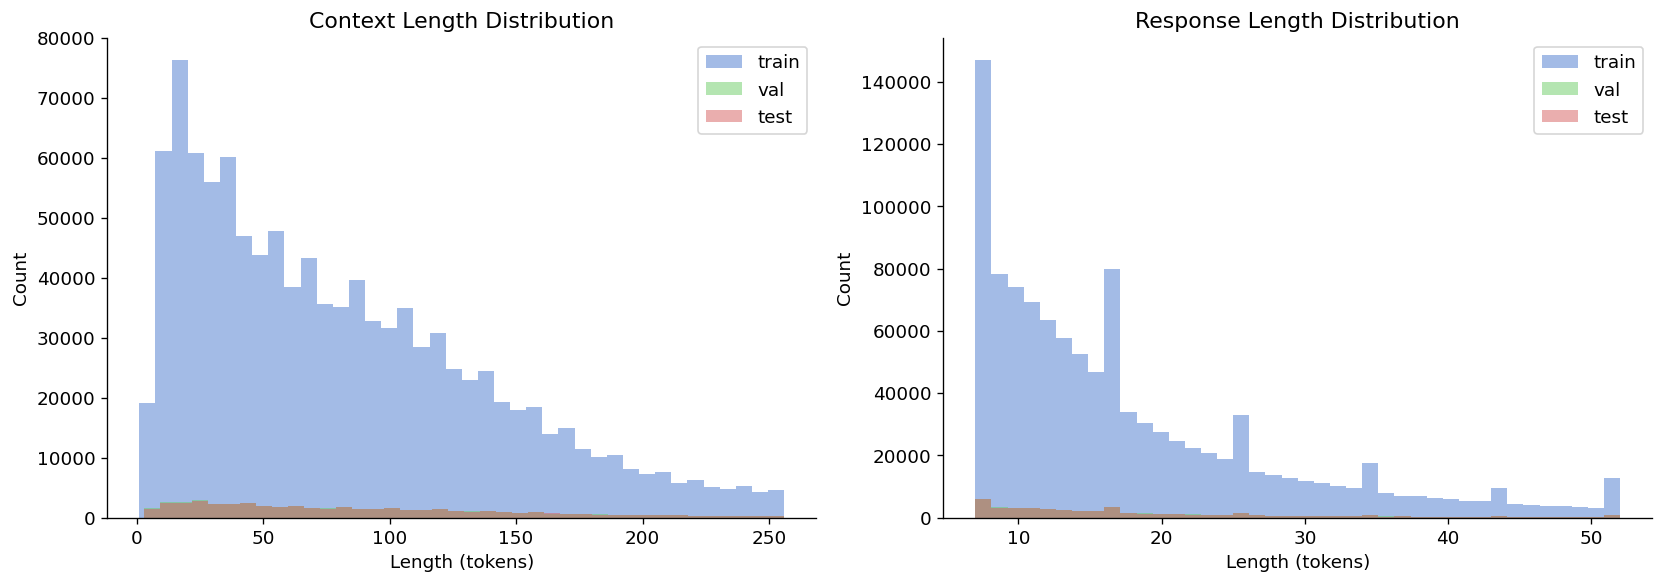

In [12]:
# === SECTION E.2: Overlaid length histograms (ctx + resp, splits as colors) ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
SPLIT_COLORS = {'train': '#4878CF', 'val': '#6ACC65', 'test': '#D65F5F'}

for ax, seq_type, max_len, title in [
    (axes[0], 'ctx',  MAX_CTX_TOKENS + 10, 'Context Length Distribution'),
    (axes[1], 'resp', MAX_RESP_TOKENS + 12, 'Response Length Distribution'),
]:
    for sname, (cl, rl) in all_lens.items():
        arr = cl if seq_type == 'ctx' else rl
        if len(arr) == 0: continue
        ax.hist(np.clip(arr, 0, max_len), bins=40, alpha=0.5,
                color=SPLIT_COLORS[sname], label=sname, edgecolor='none')
    ax.set_xlabel('Length (tokens)')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend()

fig.tight_layout()
_save_fig(fig, 'e2_length_histograms')
plt.show()


In [13]:
# === NUMERICAL SUMMARY: ctx / resp length percentiles by split ===
for _seq, _sidx, _title in [('ctx', 0, 'Context'), ('resp', 1, 'Response')]:
    _t = Table(title=f'{_title} Length Percentiles (tokens) by Split', box=box.SIMPLE_HEAVY)
    _t.add_column('Metric')
    for _s in ['train','val','test']: _t.add_column(_s, justify='right')
    for _m, _p in [('min',None),('p10',10),('p25',25),('median',50),
                    ('mean',None),('p75',75),('p90',90),('p95',95),('p99',99),('max',None)]:
        _row = [_m]
        for _s in ['train','val','test']:
            _arr = all_lens[_s][_sidx]
            if len(_arr) == 0: _row.append('N/A'); continue
            if _p is not None: _row.append(f'{np.percentile(_arr,_p):.0f}')
            elif _m == 'min':  _row.append(str(int(_arr.min())))
            elif _m == 'max':  _row.append(str(int(_arr.max())))
            else:              _row.append(f'{_arr.mean():.1f}')
        _t.add_row(*_row)
    console.print(_t)


   Context Length Percentiles   
       (tokens) by Split        
                                
  Metric   train    val   test  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  min          1      3      3  
  p10         16     17     17  
  p25         32     35     35  
  median      68     72     74  
  mean      80.9   85.9   87.5  
  p75        118    125    128  
  p90        166    177    181  
  p95        196    209    212  
  p99        241    245    247  
  max        256    256    256

  Response Length Percentiles   
       (tokens) by Split        
                                
  Metric   train    val   test  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  min          7      7      7  
  p10          8      8      8  
  p25         10     10     10  
  median      14     15     15  
  mean      17.8   18.5   18.7  
  p75         22     23     24  
  p90         33     35     36  
  p95         41     42     43  
  p99         51     52     52  
  max         52     52     52

Saved → C:\git\nlp-final-project\notebooks\visualizations\e3_ctx_resp_scatter.png

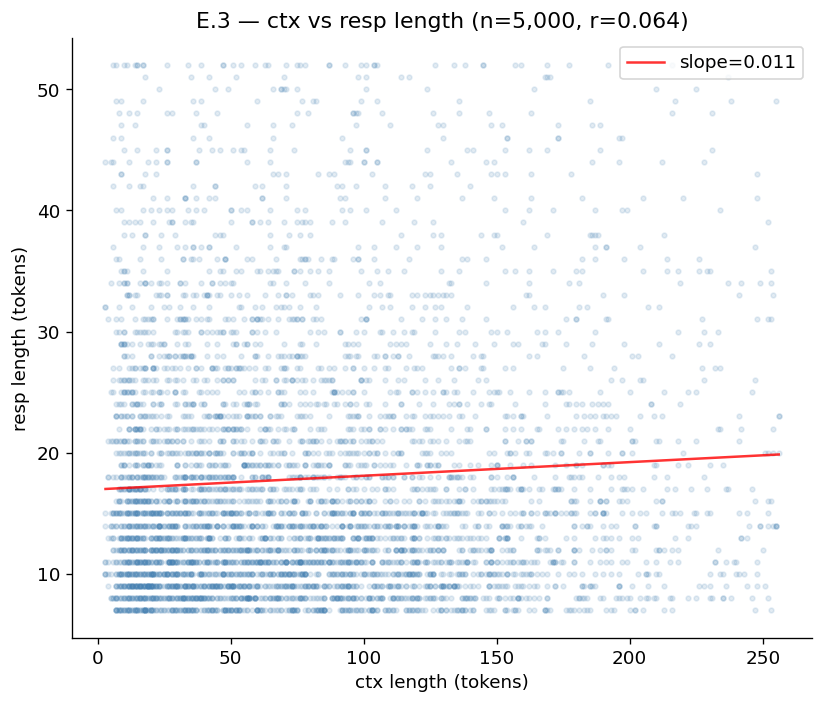

Pearson r = 0.0642  (p = 5.54e-06)

In [14]:
# === SECTION E.3: Scatter ctx_len vs resp_len (5000-pt train sample, Pearson r) ===

from scipy import stats as scipy_stats

cl_train, rl_train = all_lens['train']
n_scatter = min(5000, len(cl_train))
idx = np.random.choice(len(cl_train), n_scatter, replace=False)
cx, ry = cl_train[idx], rl_train[idx]

r_val, p_val = scipy_stats.pearsonr(cx, ry)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(cx, ry, alpha=0.15, s=8, color='steelblue')
ax.set_xlabel('ctx length (tokens)')
ax.set_ylabel('resp length (tokens)')
ax.set_title(f'E.3 — ctx vs resp length (n={n_scatter:,}, r={r_val:.3f})')
m, b = np.polyfit(cx, ry, 1)
xline = np.linspace(cx.min(), cx.max(), 100)
ax.plot(xline, m*xline + b, 'r-', lw=1.5, alpha=0.8, label=f'slope={m:.3f}')
ax.legend()
fig.tight_layout()
_save_fig(fig, 'e3_ctx_resp_scatter')
plt.show()
console.print(f'Pearson r = {r_val:.4f}  (p = {p_val:.2e})')


In [15]:
# === NUMERICAL SUMMARY: ctx vs resp length correlation ===
console.print(f'[bold]Pearson r[/bold] = {r_val:.4f}  (p = {p_val:.2e})')
console.print(f'[bold]Linear fit[/bold]: resp_len = {m:.4f} × ctx_len + {b:.2f}')
_strength = 'weak' if abs(r_val) < 0.3 else ('moderate' if abs(r_val) < 0.6 else 'strong')
_direction = 'positive' if r_val > 0 else 'negative'
console.print(f'[bold]Interpretation[/bold]: {_strength} {_direction} correlation')
console.print(f'[bold]ctx range[/bold]: {int(cx.min())}–{int(cx.max())}  '
              f'[bold]resp range[/bold]: {int(ry.min())}–{int(ry.max())}')


Pearson r = 0.0642  (p = 5.54e-06)

Linear fit: resp_len = 0.0112 × ctx_len + 16.98

Interpretation: weak positive correlation

ctx range: 3–256  resp range: 7–52

In [16]:
# === SECTION E.4: Truncation check ===

# ctx_len >= MAX_CTX_TOKENS means it hit the truncation limit
# resp_len >= MAX_RESP_TOKENS+2 means resp hit limit (includes SOS+EOS)
RESP_MAX_WITH_TOKENS = MAX_RESP_TOKENS + 2

t = Table(title=f'Truncation Check (ctx≥{MAX_CTX_TOKENS}, resp≥{RESP_MAX_WITH_TOKENS})', box=box.ROUNDED)
t.add_column('Split', style='cyan')
t.add_column('Total pairs', justify='right')
t.add_column('ctx at limit', justify='right')
t.add_column('ctx truncated %', justify='right')
t.add_column('resp at limit', justify='right')
t.add_column('resp truncated %', justify='right')
for sname, (cl, rl) in all_lens.items():
    if len(cl) == 0:
        t.add_row(sname, '0', '—', '—', '—', '—')
        continue
    n_ctx_trunc  = int((cl >= MAX_CTX_TOKENS).sum())
    n_resp_trunc = int((rl >= RESP_MAX_WITH_TOKENS).sum())
    t.add_row(sname, f'{len(cl):,}',
              f'{n_ctx_trunc:,}', f'{100*n_ctx_trunc/len(cl):.1f}%',
              f'{n_resp_trunc:,}', f'{100*n_resp_trunc/len(rl):.1f}%')
console.print(t)


                            Truncation Check (ctx≥256, resp≥52)                            
╭───────┬─────────────┬──────────────┬─────────────────┬───────────────┬──────────────────╮
│ Split │ Total pairs │ ctx at limit │ ctx truncated % │ resp at limit │ resp truncated % │
├───────┼─────────────┼──────────────┼─────────────────┼───────────────┼──────────────────┤
│ train │   1,070,445 │          439 │            0.0% │         9,840 │             0.9% │
│ val   │      47,791 │           24 │            0.1% │           568 │             1.2% │
│ test  │      47,805 │           32 │            0.1% │           617 │             1.3% │
╰───────┴─────────────┴──────────────┴─────────────────┴───────────────┴──────────────────╯

Saved → C:\git\nlp-final-project\notebooks\visualizations\e5_resp_len_dist.png

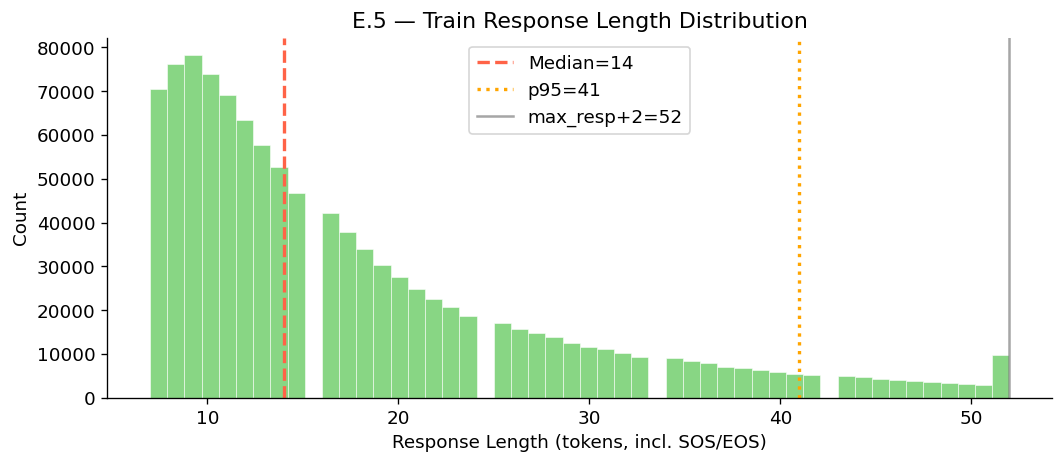

In [17]:
# === SECTION E.5: Response length distribution with median/p95 lines ===

fig, ax = plt.subplots(figsize=(9, 4))
rl = all_lens['train'][1]
ax.hist(rl, bins=50, color='#6ACC65', alpha=0.8, edgecolor='white', linewidth=0.4)
med = np.median(rl)
p95 = np.percentile(rl, 95)
ax.axvline(med, color='tomato', lw=2, ls='--', label=f'Median={med:.0f}')
ax.axvline(p95, color='orange', lw=2, ls=':', label=f'p95={p95:.0f}')
ax.axvline(RESP_MAX_WITH_TOKENS, color='gray', lw=1.5, ls='-', alpha=0.7,
           label=f'max_resp+2={RESP_MAX_WITH_TOKENS}')
ax.set_xlabel('Response Length (tokens, incl. SOS/EOS)')
ax.set_ylabel('Count')
ax.set_title('E.5 — Train Response Length Distribution')
ax.legend()
fig.tight_layout()
_save_fig(fig, 'e5_resp_len_dist')
plt.show()


In [18]:
# === NUMERICAL SUMMARY: Train response length percentiles ===
_rl = all_lens['train'][1]
t_rd = Table(title='Train Response Length Percentile Table (tokens, incl. SOS/EOS)', box=box.SIMPLE_HEAVY)
t_rd.add_column('Metric'); t_rd.add_column('Value', justify='right')
for _m, _v in [('Count',    f'{len(_rl):,}'),
               ('Min',       f'{_rl.min()}'),
               ('p10',       f'{np.percentile(_rl,10):.0f}'),
               ('p25',       f'{np.percentile(_rl,25):.0f}'),
               ('Median',    f'{np.median(_rl):.0f}'),
               ('Mean',      f'{_rl.mean():.2f}'),
               ('p75',       f'{np.percentile(_rl,75):.0f}'),
               ('p90',       f'{np.percentile(_rl,90):.0f}'),
               ('p95',       f'{np.percentile(_rl,95):.0f}'),
               ('p99',       f'{np.percentile(_rl,99):.0f}'),
               ('Max',       f'{_rl.max()}'),
               (f'<= max_resp+2 ({RESP_MAX_WITH_TOKENS})', f'{100*(_rl<=RESP_MAX_WITH_TOKENS).mean():.2f}%')]:
    t_rd.add_row(_m, _v)
console.print(t_rd)


 Train Response Length Percentile 
  Table (tokens, incl. SOS/EOS)   
                                  
  Metric                   Value  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  Count                1,070,445  
  Min                          7  
  p10                          8  
  p25                         10  
  Median                      14  
  Mean                     17.79  
  p75                         22  
  p90                         33  
  p95                         41  
  p99                         51  
  Max                         52  
  <= max_resp+2 (52)     100.00%

## Section F — Token Distribution & Data Quality

In [19]:
# === SECTION F.1: Top-30 most frequent tokens (train ctx+resp) ===

console.print('[bold]Building token frequency counter from train...[/bold]')
token_counter = Counter()
for rec in train_data:
    token_counter.update(rec.get('ctx', []))
    token_counter.update(rec.get('resp', []))

t = Table(title='Top-30 Most Frequent Tokens (train)', box=box.ROUNDED)
t.add_column('Rank', justify='right', style='dim')
t.add_column('ID', justify='right')
t.add_column('Piece', style='cyan')
t.add_column('Frequency', justify='right')
for rank, (tid, freq) in enumerate(token_counter.most_common(30), 1):
    piece = sp.id_to_piece(tid) if tid < sp.GetPieceSize() else f'<id={tid}>'
    t.add_row(str(rank), str(tid), piece, f'{freq:,}')
console.print(t)


Building token frequency counter from train...

  Top-30 Most Frequent Tokens (train)   
╭──────┬───────┬───────────┬───────────╮
│ Rank │    ID │ Piece     │ Frequency │
├──────┼───────┼───────────┼───────────┤
│    1 │     9 │ ▁i        │ 3,837,131 │
│    2 │     7 │ ▁__eot__  │ 3,345,605 │
│    3 │    19 │ ▁the      │ 3,331,275 │
│    4 │    32 │ ▁.        │ 2,885,636 │
│    5 │    30 │ ▁to       │ 2,689,713 │
│    6 │    38 │ ▁it       │ 2,386,789 │
│    7 │    46 │ ▁is       │ 2,002,388 │
│    8 │    41 │ ▁you      │ 1,987,723 │
│    9 │    11 │ ▁a        │ 1,779,562 │
│   10 │    59 │ ▁and      │ 1,456,668 │
│   11 │    62 │ ▁that     │ 1,265,163 │
│   12 │    61 │ ▁not      │ 1,256,963 │
│   13 │     2 │ <sos>     │ 1,070,445 │
│   14 │     3 │ <eos>     │ 1,070,445 │
│   15 │    56 │ ▁do       │ 1,050,148 │
│   16 │    43 │ ▁in       │ 1,024,559 │
│   17 │    72 │ ▁have     │   973,165 │
│   18 │ 31983 │ -         │   824,865 │
│   19 │    66 │ ▁on       │   759,924 │
│   20 │    81 │ ▁for      │   738,591 │
│   21 │    89 │ ▁what     │   725,156 │
│   22 │    74 │ ▁can      │   712,222 │
│   23 │    86 │ ▁of       │   699,030 │
│   24 │    95 │ ▁but      │   698,541 │
│   25 │     5 │ ▁__path__ │   680,604 │
│   26 │   100 │ ▁my       │   637,760 │
│   27 │    99 │ ▁with     │   616,466 │
│   28 │ 31986 │ '         │   590,996 │
│   29 │   119 │ ▁if       │   536,999 │
│   30 │   126 │ ▁ubuntu   │   536,253 │
╰──────┴───────┴───────────┴───────────╯

In [20]:
# === SECTION F.2: UNK (id=1) occurrences per split ===

t = Table(title='UNK (id=1) Occurrences per Split', box=box.SIMPLE_HEAVY)
t.add_column('Split', style='cyan')
t.add_column('UNK count', justify='right')
t.add_column('Total tokens', justify='right')
t.add_column('UNK rate', justify='right')
for sname, sdata in [('train', train_data), ('val', val_data), ('test', test_data)]:
    unk = sum(1 for r in sdata for seq in (r.get('ctx',[]), r.get('resp',[])) for tid in seq if tid == UNK_ID)
    tot = sum(len(r.get('ctx',[])) + len(r.get('resp',[])) for r in sdata)
    rate = unk/tot if tot > 0 else 0
    color = 'green' if rate < 0.001 else ('yellow' if rate < 0.01 else 'red')
    t.add_row(sname, f'{unk:,}', f'{tot:,}', f'[{color}]{rate:.5%}[/{color}]')
console.print(t)


       UNK (id=1) Occurrences per Split        
                                               
  Split   UNK count   Total tokens   UNK rate  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  train           0    105,623,620   0.00000%  
  val             0      4,989,365   0.00000%  
  test            0      5,077,426   0.00000%

In [21]:
# === SECTION F.3: Type-Token Ratio (TTR) per split ===

t = Table(title='Type-Token Ratio (TTR) per Split', box=box.SIMPLE_HEAVY)
t.add_column('Split', style='cyan')
t.add_column('Unique types', justify='right')
t.add_column('Total tokens', justify='right')
t.add_column('TTR', justify='right')
for sname, sdata in [('train', train_data), ('val', val_data), ('test', test_data)]:
    all_toks = [tid for r in sdata for seq in (r.get('ctx',[]), r.get('resp',[])) for tid in seq]
    n_types  = len(set(all_toks))
    n_tokens = len(all_toks)
    ttr = n_types / n_tokens if n_tokens > 0 else 0
    t.add_row(sname, f'{n_types:,}', f'{n_tokens:,}', f'{ttr:.4f}')
console.print(t)


        Type-Token Ratio (TTR) per Split        
                                                
  Split   Unique types   Total tokens      TTR  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  train         31,901    105,623,620   0.0003  
  val           22,957      4,989,365   0.0046  
  test          23,129      5,077,426   0.0046

Saved → C:\git\nlp-final-project\notebooks\visualizations\f4_len_ratio.png

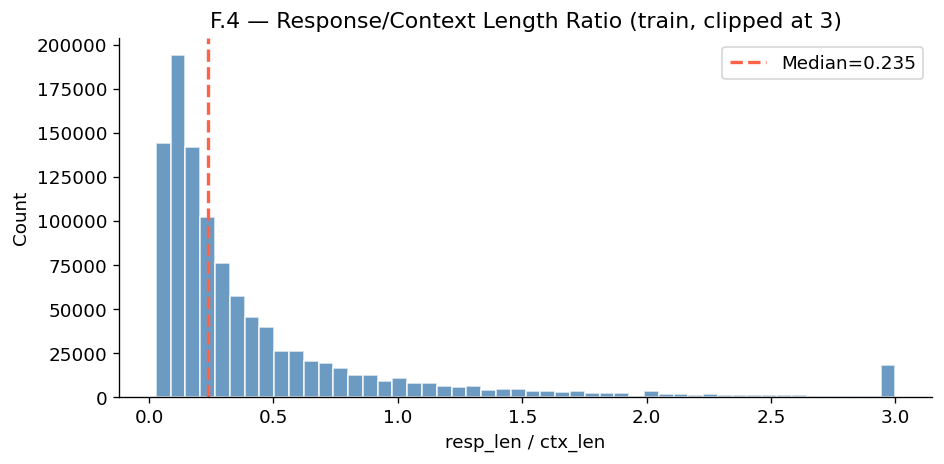

In [22]:
# === SECTION F.4: Length-ratio distribution (resp_len/ctx_len, train) ===

cl, rl = all_lens['train']
mask = cl > 0
ratios = rl[mask] / cl[mask]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.clip(ratios, 0, 3), bins=50, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(np.median(ratios), color='tomato', lw=2, ls='--', label=f'Median={np.median(ratios):.3f}')
ax.set_xlabel('resp_len / ctx_len')
ax.set_ylabel('Count')
ax.set_title('F.4 — Response/Context Length Ratio (train, clipped at 3)')
ax.legend()
fig.tight_layout()
_save_fig(fig, 'f4_len_ratio')
plt.show()


In [23]:
# === NUMERICAL SUMMARY: Length ratio statistics ===
t_rp = Table(title='resp_len / ctx_len Ratio Statistics (train)', box=box.SIMPLE_HEAVY)
t_rp.add_column('Metric'); t_rp.add_column('Value', justify='right')
for _m, _v in [('Count', f'{len(ratios):,}'),
               ('Min',    f'{ratios.min():.3f}'),
               ('p10',   f'{np.percentile(ratios,10):.3f}'),
               ('p25',   f'{np.percentile(ratios,25):.3f}'),
               ('Median',f'{np.median(ratios):.3f}'),
               ('Mean',  f'{ratios.mean():.3f}'),
               ('p75',   f'{np.percentile(ratios,75):.3f}'),
               ('p90',   f'{np.percentile(ratios,90):.3f}'),
               ('p95',   f'{np.percentile(ratios,95):.3f}'),
               ('p99',   f'{np.percentile(ratios,99):.3f}'),
               ('Max',   f'{ratios.max():.3f}')]:
    t_rp.add_row(_m, _v)
console.print(t_rp)

t_rb = Table(title='Length Ratio Band Distribution', box=box.SIMPLE_HEAVY)
t_rb.add_column('resp/ctx band'); t_rb.add_column('Count', justify='right'); t_rb.add_column('%', justify='right')
for _label, _lo, _hi in [('<0.1',0,0.1),('0.1–0.25',0.1,0.25),('0.25–0.5',0.25,0.5),
                           ('0.5–1.0',0.5,1.0),('1.0–2.0',1.0,2.0),('>2.0',2.0,9999)]:
    _cnt = int(((ratios>=_lo)&(ratios<_hi)).sum())
    t_rb.add_row(_label, f'{_cnt:,}', f'{100*_cnt/len(ratios):.1f}%')
console.print(t_rb)


  resp_len / ctx_len  
   Ratio Statistics   
       (train)        
                      
  Metric       Value  
 ━━━━━━━━━━━━━━━━━━━━ 
  Count    1,070,445  
  Min          0.027  
  p10          0.076  
  p25          0.123  
  Median       0.235  
  Mean         0.477  
  p75          0.508  
  p90          1.083  
  p95          1.692  
  p99          3.714  
  Max         49.000

  Length Ratio Band Distribution   
                                   
  resp/ctx band     Count       %  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  <0.1            189,726   17.7%  
  0.1–0.25        367,025   34.3%  
  0.25–0.5        236,442   22.1%  
  0.5–1.0         153,560   14.3%  
  1.0–2.0          82,185    7.7%  
  >2.0             41,507    3.9%

In [24]:
# === SECTION F.5: Duplicate detection in train (exact ctx+resp) ===

console.print('[bold]Checking for duplicate (ctx, resp) pairs in train...[/bold]')
seen_hashes = set()
n_dups = 0
for rec in train_data:
    key = (tuple(rec.get('ctx',[])), tuple(rec.get('resp',[])))
    h = hash(key)
    if h in seen_hashes:
        n_dups += 1
    else:
        seen_hashes.add(h)
color = 'green' if n_dups == 0 else 'red'
console.print(f'Duplicate pairs: [{color}]{n_dups:,}[/{color}] out of {len(train_data):,} train pairs '
              f'({100*n_dups/max(len(train_data),1):.3f}%)')
if n_dups == 0:
    console.print('[bold green]✓ No duplicates found — dedup working correctly.[/bold green]')
else:
    console.print('[bold red]✗ Duplicates found — check stage 4/6 dedup logic.[/bold red]')


Checking for duplicate (ctx, resp) pairs in train...

Duplicate pairs: 0 out of 1,070,445 train pairs (0.000%)

✓ No duplicates found — dedup working correctly.

In [25]:
# === SECTION F.6: Short response check (< 5 content tokens) ===

t = Table(title='Short Response Check (< 5 content tokens)', box=box.SIMPLE_HEAVY)
t.add_column('Split', style='cyan')
t.add_column('Short (<5)', justify='right')
t.add_column('Total', justify='right')
t.add_column('%', justify='right')
for sname, sdata in [('train', train_data), ('val', val_data), ('test', test_data)]:
    n_short = 0
    for rec in sdata:
        resp = rec.get('resp', [])
        content = [tid for tid in resp if tid not in (PAD_ID, SOS_ID, EOS_ID)]
        if len(content) < 5:
            n_short += 1
    pct = 100*n_short/max(len(sdata),1)
    color = 'green' if pct < 5 else ('yellow' if pct < 15 else 'red')
    t.add_row(sname, f'{n_short:,}', f'{len(sdata):,}', f'[{color}]{pct:.1f}%[/{color}]')
console.print(t)


Short Response Check (< 5 content tokens)
                                         
  Split   Short (<5)       Total      %  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  train            0   1,070,445   0.0%  
  val              0      47,791   0.0%  
  test             0      47,805   0.0%

In [26]:
# === SECTION F.7: ctx sequences containing __eot__ + avg turns per ctx ===

t = Table(title='__eot__ Turn Structure in ctx', box=box.SIMPLE_HEAVY)
t.add_column('Split', style='cyan')
t.add_column('Has ≥1 __eot__', justify='right')
t.add_column('% with __eot__', justify='right')
t.add_column('Avg turns/ctx', justify='right')
for sname, sdata in [('train', train_data), ('val', val_data), ('test', test_data)]:
    eot_counts = [rec.get('ctx', []).count(EOT_ID) for rec in sdata]
    n_has_eot = sum(1 for c in eot_counts if c > 0)
    avg_turns = (sum(c + 1 for c in eot_counts) / max(len(eot_counts), 1))  # turns = eot_count + 1
    pct_eot = 100 * n_has_eot / max(len(sdata), 1)
    t.add_row(sname, f'{n_has_eot:,}', f'{pct_eot:.1f}%', f'{avg_turns:.2f}')
console.print(t)


               __eot__ Turn Structure in ctx               
                                                           
  Split   Has ≥1 __eot__   % with __eot__   Avg turns/ctx  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  train          783,713            73.2%            4.13  
  val             35,282            73.8%            4.07  
  test            35,348            73.9%            4.08

## Section G — Split Integrity Checks

In [27]:
# === SECTION G.1: Cross-split source leakage (by ctx sequence hash) ===

console.print('[bold]Checking for cross-split leakage...[/bold]')
split_ctx_hashes = {}
for sname, sdata in [('train', train_data), ('val', val_data), ('test', test_data)]:
    split_ctx_hashes[sname] = {hash(tuple(r.get('ctx', []))) for r in sdata}

t = Table(title='Cross-Split Context Hash Leakage', box=box.ROUNDED)
t.add_column('Split A', style='cyan')
t.add_column('Split B', style='cyan')
t.add_column('Overlap', justify='right')
t.add_column('Status', justify='center')
pairs_checked = [('train','val'), ('train','test'), ('val','test')]
for sa, sb in pairs_checked:
    overlap = len(split_ctx_hashes[sa] & split_ctx_hashes[sb])
    status = '[bold green]PASS (0)[/bold green]' if overlap == 0 else f'[bold red]FAIL ({overlap:,})[/bold red]'
    t.add_row(sa, sb, str(overlap), status)
console.print(t)


Checking for cross-split leakage...

     Cross-Split Context Hash Leakage      
╭─────────┬─────────┬─────────┬───────────╮
│ Split A │ Split B │ Overlap │  Status   │
├─────────┼─────────┼─────────┼───────────┤
│ train   │ val     │      51 │ FAIL (51) │
│ train   │ test    │      43 │ FAIL (43) │
│ val     │ test    │      13 │ FAIL (13) │
╰─────────┴─────────┴─────────┴───────────╯

In [28]:
# === SECTION G.2: Token ID range check [0, VOCAB_SIZE) ===

t = Table(title=f'Token ID Range Check [0, {VOCAB_SIZE})', box=box.ROUNDED)
t.add_column('Split', style='cyan')
t.add_column('Min ID', justify='right')
t.add_column('Max ID', justify='right')
t.add_column('Out-of-range', justify='right')
t.add_column('Status', justify='center')
for sname, sdata in [('train', train_data), ('val', val_data), ('test', test_data)]:
    all_ids = [tid for r in sdata for seq in (r.get('ctx',[]), r.get('resp',[])) for tid in seq]
    if not all_ids:
        t.add_row(sname, '—', '—', '—', '[yellow]EMPTY[/yellow]')
        continue
    min_id = min(all_ids)
    max_id = max(all_ids)
    oor    = sum(1 for tid in all_ids if tid < 0 or tid >= VOCAB_SIZE)
    status = '[bold green]PASS[/bold green]' if oor == 0 else f'[bold red]FAIL ({oor})[/bold red]'
    t.add_row(sname, str(min_id), str(max_id), str(oor), status)
console.print(t)


          Token ID Range Check [0, 32000)          
╭───────┬────────┬────────┬──────────────┬────────╮
│ Split │ Min ID │ Max ID │ Out-of-range │ Status │
├───────┼────────┼────────┼──────────────┼────────┤
│ train │      2 │  31999 │            0 │  PASS  │
│ val   │      2 │  31999 │            0 │  PASS  │
│ test  │      2 │  31999 │            0 │  PASS  │
╰───────┴────────┴────────┴──────────────┴────────╯

In [29]:
# === SECTION G.3: SOS/EOS boundary verification ===

t = Table(title='SOS/EOS Boundary Verification', box=box.ROUNDED)
t.add_column('Split', style='cyan')
t.add_column('resp starts SOS', justify='right')
t.add_column('resp ends EOS', justify='right')
t.add_column('ctx has SOS/EOS', justify='right')
t.add_column('Status', justify='center')
for sname, sdata in [('train', train_data), ('val', val_data), ('test', test_data)]:
    if not sdata:
        t.add_row(sname, '—', '—', '—', '[yellow]EMPTY[/yellow]')
        continue
    ok_sos   = sum(1 for r in sdata if r.get('resp', [SOS_ID])[0] == SOS_ID)
    ok_eos   = sum(1 for r in sdata if r.get('resp', [])[-1:] == [EOS_ID])
    ctx_leak = sum(1 for r in sdata if SOS_ID in r.get('ctx', []) or EOS_ID in r.get('ctx', []))
    n = len(sdata)
    s_sos   = f'{100*ok_sos/n:.1f}%'
    s_eos   = f'{100*ok_eos/n:.1f}%'
    c_leak  = str(ctx_leak)
    all_ok = (ok_sos == n and ok_eos == n and ctx_leak == 0)
    status = '[bold green]PASS[/bold green]' if all_ok else '[bold red]FAIL[/bold red]'
    t.add_row(sname, s_sos, s_eos, f'[{"red" if ctx_leak>0 else "green"}]{c_leak}[/{"red" if ctx_leak>0 else "green"}]', status)
console.print(t)


                    SOS/EOS Boundary Verification                     
╭───────┬─────────────────┬───────────────┬─────────────────┬────────╮
│ Split │ resp starts SOS │ resp ends EOS │ ctx has SOS/EOS │ Status │
├───────┼─────────────────┼───────────────┼─────────────────┼────────┤
│ train │          100.0% │        100.0% │               0 │  PASS  │
│ val   │          100.0% │        100.0% │               0 │  PASS  │
│ test  │          100.0% │        100.0% │               0 │  PASS  │
╰───────┴─────────────────┴───────────────┴─────────────────┴────────╯

In [30]:
# === SECTION G.4: __eot__ presence in ctx ===

t = Table(title='__eot__ Presence in ctx Sequences', box=box.ROUNDED)
t.add_column('Split', style='cyan')
t.add_column('ctx with __eot__', justify='right')
t.add_column('% with __eot__', justify='right')
t.add_column('Status', justify='center')
for sname, sdata in [('train', train_data), ('val', val_data), ('test', test_data)]:
    if not sdata:
        t.add_row(sname, '—', '—', '[yellow]EMPTY[/yellow]')
        continue
    n_has = sum(1 for r in sdata if EOT_ID in r.get('ctx', []))
    pct   = 100 * n_has / len(sdata)
    # Most ctx should have __eot__ (multi-turn context)
    # Single-turn dialogs (no eot) are acceptable but should be minority
    status = '[green]OK[/green]' if pct > 20 else '[yellow]WARN (low eot rate)[/yellow]'
    t.add_row(sname, f'{n_has:,}', f'{pct:.1f}%', status)
console.print(t)


          __eot__ Presence in ctx Sequences           
╭───────┬──────────────────┬────────────────┬────────╮
│ Split │ ctx with __eot__ │ % with __eot__ │ Status │
├───────┼──────────────────┼────────────────┼────────┤
│ train │          783,713 │          73.2% │   OK   │
│ val   │           35,282 │          73.8% │   OK   │
│ test  │           35,348 │          73.9% │   OK   │
╰───────┴──────────────────┴────────────────┴────────╯

In [31]:
# === SECTION G.5: Final pass/fail checklist ===

checks = []
for sname, sdata in [('train', train_data), ('val', val_data), ('test', test_data)]:
    if not sdata:
        continue
    n = len(sdata)
    # G.1 leakage
    for other in ('val', 'test') if sname == 'train' else ('train',):
        if other in split_ctx_hashes:
            ov = len(split_ctx_hashes[sname] & split_ctx_hashes[other])
            checks.append((f'{sname}↔{other} leakage', ov == 0, f'{ov} overlap'))
    # G.3 SOS/EOS
    ok_sos = sum(1 for r in sdata if r.get('resp', [SOS_ID])[0] == SOS_ID)
    ok_eos = sum(1 for r in sdata if r.get('resp', [])[-1:] == [EOS_ID])
    ctx_leak = sum(1 for r in sdata if SOS_ID in r.get('ctx',[]) or EOS_ID in r.get('ctx',[]))
    checks.append((f'{sname} resp SOS', ok_sos == n, f'{ok_sos}/{n}'))
    checks.append((f'{sname} resp EOS', ok_eos == n, f'{ok_eos}/{n}'))
    checks.append((f'{sname} ctx no SOS/EOS', ctx_leak == 0, f'{ctx_leak} leaks'))

t = Table(title='G — Final Integrity Checklist', box=box.ROUNDED)
t.add_column('Check', style='cyan')
t.add_column('Detail')
t.add_column('Result', justify='center')
all_pass = True
for name, ok, detail in checks:
    result = '[bold green]PASS[/bold green]' if ok else '[bold red]FAIL[/bold red]'
    if not ok: all_pass = False
    t.add_row(name, detail, result)
console.print(t)
console.print(Panel(
    f'[bold {"green" if all_pass else "red"}]Overall: {"ALL CHECKS PASSED" if all_pass else "SOME CHECKS FAILED"}[/bold {"green" if all_pass else "red"}]',
    border_style='green' if all_pass else 'red'
))


           G — Final Integrity Checklist           
╭──────────────────────┬─────────────────┬────────╮
│ Check                │ Detail          │ Result │
├──────────────────────┼─────────────────┼────────┤
│ train↔val leakage    │ 51 overlap      │  FAIL  │
│ train↔test leakage   │ 43 overlap      │  FAIL  │
│ train resp SOS       │ 1070445/1070445 │  PASS  │
│ train resp EOS       │ 1070445/1070445 │  PASS  │
│ train ctx no SOS/EOS │ 0 leaks         │  PASS  │
│ val↔train leakage    │ 51 overlap      │  FAIL  │
│ val resp SOS         │ 47791/47791     │  PASS  │
│ val resp EOS         │ 47791/47791     │  PASS  │
│ val ctx no SOS/EOS   │ 0 leaks         │  PASS  │
│ test↔train leakage   │ 43 overlap      │  FAIL  │
│ test resp SOS        │ 47805/47805     │  PASS  │
│ test resp EOS        │ 47805/47805     │  PASS  │
│ test ctx no SOS/EOS  │ 0 leaks         │  PASS  │
╰──────────────────────┴─────────────────┴────────╯

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Overall: SOME CHECKS FAILED                                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Section H — Summary Dashboard

In [32]:
# === SECTION H.1: Rich summary table ===

t = Table(title='Stage 6 Summary', box=box.ROUNDED)
t.add_column('Metric', style='cyan')
t.add_column('Train', justify='right')
t.add_column('Val', justify='right')
t.add_column('Test', justify='right')
rows_data = [
    ('Pairs', [f'{len(d):,}' for d in [train_data, val_data, test_data]]),
    ('Vocab size', [str(VOCAB_SIZE)]*3),
    ('Mean ctx len', [f'{all_lens[s][0].mean():.1f}' if len(all_lens[s][0]) else '—' for s in ["train","val","test"]]),
    ('Median ctx len', [f'{np.median(all_lens[s][0]):.0f}' if len(all_lens[s][0]) else '—' for s in ["train","val","test"]]),
    ('Mean resp len', [f'{all_lens[s][1].mean():.1f}' if len(all_lens[s][1]) else '—' for s in ["train","val","test"]]),
    ('Median resp len', [f'{np.median(all_lens[s][1]):.0f}' if len(all_lens[s][1]) else '—' for s in ["train","val","test"]]),
]
for name, vals in rows_data:
    t.add_row(name, *vals)
console.print(t)


                 Stage 6 Summary                 
╭─────────────────┬───────────┬────────┬────────╮
│ Metric          │     Train │    Val │   Test │
├─────────────────┼───────────┼────────┼────────┤
│ Pairs           │ 1,070,445 │ 47,791 │ 47,805 │
│ Vocab size      │     32000 │  32000 │  32000 │
│ Mean ctx len    │      80.9 │   85.9 │   87.5 │
│ Median ctx len  │        68 │     72 │     74 │
│ Mean resp len   │      17.8 │   18.5 │   18.7 │
│ Median resp len │        14 │     15 │     15 │
╰─────────────────┴───────────┴────────┴────────╯

Saved → C:\git\nlp-final-project\notebooks\visualizations\h2_dashboard.png

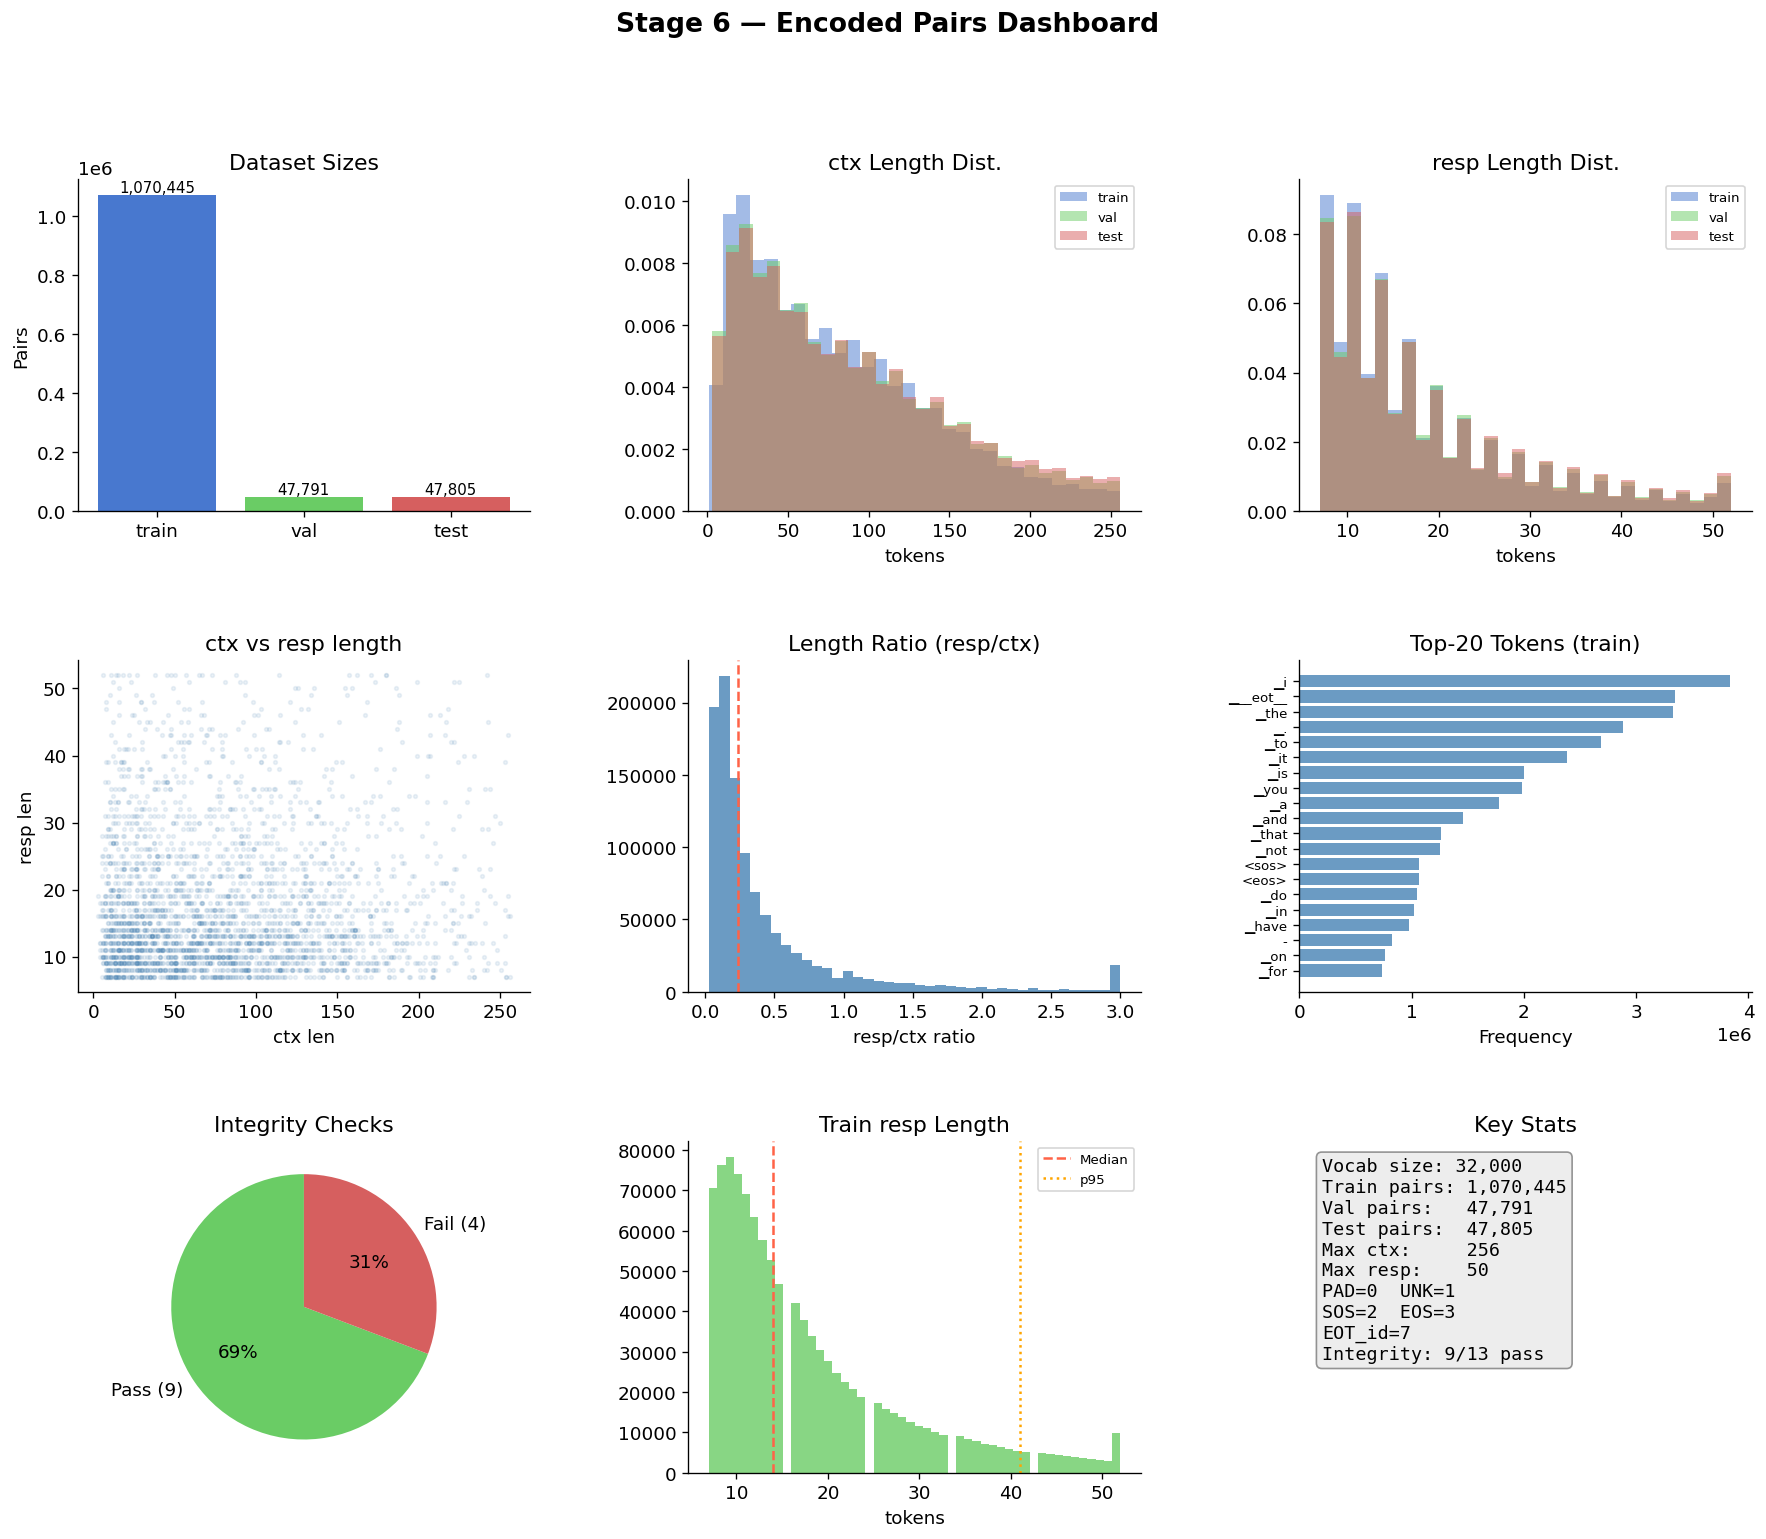

In [33]:
# === SECTION H.2: Multi-panel matplotlib dashboard ===

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Dataset sizes
ax1 = fig.add_subplot(gs[0, 0])
split_names = ['train', 'val', 'test']
sizes = [len(train_data), len(val_data), len(test_data)]
ax1.bar(split_names, sizes, color=['#4878CF','#6ACC65','#D65F5F'])
for i, v in enumerate(sizes):
    ax1.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
ax1.set_title('Dataset Sizes')
ax1.set_ylabel('Pairs')

# 2. ctx length histograms
ax2 = fig.add_subplot(gs[0, 1])
for sname, (cl, _), col in zip(split_names, [all_lens[s] for s in split_names], ['#4878CF','#6ACC65','#D65F5F']):
    if len(cl): ax2.hist(cl, bins=30, alpha=0.5, color=col, label=sname, density=True)
ax2.set_title('ctx Length Dist.')
ax2.set_xlabel('tokens')
ax2.legend(fontsize=8)

# 3. resp length histograms
ax3 = fig.add_subplot(gs[0, 2])
for sname, (_, rl), col in zip(split_names, [all_lens[s] for s in split_names], ['#4878CF','#6ACC65','#D65F5F']):
    if len(rl): ax3.hist(rl, bins=30, alpha=0.5, color=col, label=sname, density=True)
ax3.set_title('resp Length Dist.')
ax3.set_xlabel('tokens')
ax3.legend(fontsize=8)

# 4. Scatter ctx vs resp
ax4 = fig.add_subplot(gs[1, 0])
cl_tr, rl_tr = all_lens['train']
n_s = min(3000, len(cl_tr))
idx = np.random.choice(len(cl_tr), n_s, replace=False)
ax4.scatter(cl_tr[idx], rl_tr[idx], alpha=0.1, s=5, color='steelblue')
ax4.set_xlabel('ctx len')
ax4.set_ylabel('resp len')
ax4.set_title('ctx vs resp length')

# 5. Length ratio
ax5 = fig.add_subplot(gs[1, 1])
mask = cl_tr > 0
ratios_plot = rl_tr[mask] / cl_tr[mask]
ax5.hist(np.clip(ratios_plot, 0, 3), bins=40, color='steelblue', alpha=0.8)
ax5.axvline(np.median(ratios_plot), color='tomato', lw=1.5, ls='--')
ax5.set_xlabel('resp/ctx ratio')
ax5.set_title('Length Ratio (resp/ctx)')

# 6. Top-20 tokens
ax6 = fig.add_subplot(gs[1, 2])
top20_ids, top20_freqs = zip(*token_counter.most_common(20))
top20_pieces = [sp.id_to_piece(tid) if tid < sp.GetPieceSize() else str(tid) for tid in top20_ids]
ax6.barh(range(20), top20_freqs[::-1], color='steelblue', alpha=0.8)
ax6.set_yticks(range(20))
ax6.set_yticklabels([p[:15] for p in top20_pieces[::-1]], fontsize=8)
ax6.set_xlabel('Frequency')
ax6.set_title('Top-20 Tokens (train)')

# 7. Integrity pie (pass/fail)
ax7 = fig.add_subplot(gs[2, 0])
n_pass = sum(1 for _, ok, _ in checks if ok)
n_fail = len(checks) - n_pass
ax7.pie([n_pass, max(n_fail, 0)], labels=[f'Pass ({n_pass})', f'Fail ({n_fail})'],
        colors=['#6ACC65', '#D65F5F'], autopct='%1.0f%%', startangle=90)
ax7.set_title('Integrity Checks')

# 8. Response length dist (train only)
ax8 = fig.add_subplot(gs[2, 1])
ax8.hist(all_lens['train'][1], bins=50, color='#6ACC65', alpha=0.8)
ax8.axvline(np.median(all_lens['train'][1]), color='tomato', lw=1.5, ls='--', label='Median')
ax8.axvline(np.percentile(all_lens['train'][1], 95), color='orange', lw=1.5, ls=':', label='p95')
ax8.legend(fontsize=8)
ax8.set_title('Train resp Length')
ax8.set_xlabel('tokens')

# 9. Key stats text
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')
stats_text = (
    f'Vocab size: {VOCAB_SIZE:,}\n'
    f'Train pairs: {len(train_data):,}\n'
    f'Val pairs:   {len(val_data):,}\n'
    f'Test pairs:  {len(test_data):,}\n'
    f'Max ctx:     {MAX_CTX_TOKENS}\n'
    f'Max resp:    {MAX_RESP_TOKENS}\n'
    f'PAD=0  UNK=1\n'
    f'SOS=2  EOS=3\n'
    f'EOT_id={EOT_ID}\n'
    f'Integrity: {n_pass}/{len(checks)} pass'
)
ax9.text(0.05, 0.95, stats_text, transform=ax9.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.4))
ax9.set_title('Key Stats')

fig.suptitle('Stage 6 — Encoded Pairs Dashboard', fontsize=16, fontweight='bold')
_save_fig(fig, 'h2_dashboard')
plt.show()


In [34]:
# === NUMERICAL SUMMARY: Dashboard key metrics ===
console.rule('[bold]Dashboard Numerical Summary[/bold]')

_total_pairs = len(train_data) + len(val_data) + len(test_data)
t_ds = Table(title='Dataset Sizes', box=box.SIMPLE_HEAVY)
t_ds.add_column('Split'); t_ds.add_column('Pairs', justify='right'); t_ds.add_column('%', justify='right')
for _n, _cnt in [('train',len(train_data)),('val',len(val_data)),('test',len(test_data)),('total',_total_pairs)]:
    t_ds.add_row(_n, f'{_cnt:,}', f'{100*_cnt/_total_pairs:.1f}%' if _n!='total' else '—')
console.print(t_ds)

_cl_tr, _rl_tr = all_lens['train']
t_ls = Table(title='Train ctx / resp Length Summary (tokens)', box=box.SIMPLE_HEAVY)
t_ls.add_column('Metric'); t_ls.add_column('ctx', justify='right'); t_ls.add_column('resp', justify='right')
for _m, _p in [('min',None),('p25',25),('median',50),('mean',None),('p75',75),('p95',95),('p99',99),('max',None)]:
    _cv = (f'{np.percentile(_cl_tr,_p):.0f}' if _p else
           (str(int(_cl_tr.min())) if _m=='min' else (str(int(_cl_tr.max())) if _m=='max' else f'{_cl_tr.mean():.1f}')))
    _rv = (f'{np.percentile(_rl_tr,_p):.0f}' if _p else
           (str(int(_rl_tr.min())) if _m=='min' else (str(int(_rl_tr.max())) if _m=='max' else f'{_rl_tr.mean():.1f}')))
    t_ls.add_row(_m, _cv, _rv)
console.print(t_ls)

t_top20 = Table(title='Top-20 Tokens in Train (ctx+resp)', box=box.SIMPLE_HEAVY)
t_top20.add_column('Rank', justify='right'); t_top20.add_column('Piece'); t_top20.add_column('Freq', justify='right')
_ttotal = sum(token_counter.values())
for _rank, (_tid, _freq) in enumerate(token_counter.most_common(20), 1):
    _piece = sp.id_to_piece(int(_tid)) if int(_tid) < sp.GetPieceSize() else str(_tid)
    t_top20.add_row(str(_rank), _piece, f'{_freq:,}')
console.print(t_top20)

t_ic = Table(title='Integrity Check Results', box=box.SIMPLE_HEAVY)
t_ic.add_column('Check'); t_ic.add_column('Result', justify='center'); t_ic.add_column('Detail')
for _name, _ok, _detail in checks:
    t_ic.add_row(_name, '[green]PASS[/green]' if _ok else '[red]FAIL[/red]', str(_detail))
console.print(t_ic)


─────────────────────────────────────────── Dashboard Numerical Summary ───────────────────────────────────────────

        Dataset Sizes        
                             
  Split       Pairs       %  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  train   1,070,445   91.8%  
  val        47,791    4.1%  
  test       47,805    4.1%  
  total   1,166,041       —

Train ctx / resp Length 
    Summary (tokens)    
                        
  Metric    ctx   resp  
 ━━━━━━━━━━━━━━━━━━━━━━ 
  min         1      7  
  p25        32     10  
  median     68     14  
  mean     80.9   17.8  
  p75       118     22  
  p95       196     41  
  p99       241     51  
  max       256     52

    Top-20 Tokens in Train     
          (ctx+resp)           
                               
  Rank   Piece           Freq  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
     1   ▁i         3,837,131  
     2   ▁__eot__   3,345,605  
     3   ▁the       3,331,275  
     4   ▁.         2,885,636  
     5   ▁to        2,689,713  
     6   ▁it        2,386,789  
     7   ▁is        2,002,388  
     8   ▁you       1,987,723  
     9   ▁a         1,779,562  
    10   ▁and       1,456,668  
    11   ▁that      1,265,163  
    12   ▁not       1,256,963  
    13   <sos>      1,070,445  
    14   <eos>      1,070,445  
    15   ▁do        1,050,148  
    16   ▁in        1,024,559  
    17   ▁have        973,165  
    18   -            824,865  
    19   ▁on          759,924  
    20   ▁for         738,591

              Integrity Check Results              
                                                   
  Check                  Result   Detail           
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  train↔val leakage       FAIL    51 overlap       
  train↔test leakage      FAIL    43 overlap       
  train resp SOS          PASS    1070445/1070445  
  train resp EOS          PASS    1070445/1070445  
  train ctx no SOS/EOS    PASS    0 leaks          
  val↔train leakage       FAIL    51 overlap       
  val resp SOS            PASS    47791/47791      
  val resp EOS            PASS    47791/47791      
  val ctx no SOS/EOS      PASS    0 leaks          
  test↔train leakage      FAIL    43 overlap       
  test resp SOS           PASS    47805/47805      
  test resp EOS           PASS    47805/47805      
  test ctx no SOS/EOS     PASS    0 leaks